# Classificação de Desastres Naturais com Dataset Real (EM-DAT)

Este notebook demonstra o processo completo de carregamento, pré-processamento, treinamento e avaliação de modelos de classificação para identificar tipos de desastres naturais com base em dados reais.


=== Modelo: KNN ===
Acurácia: 0.5477

Relatório de Classificação:
                      precision    recall  f1-score   support

             Drought       0.77      0.95      0.85       232
          Earthquake       0.41      0.42      0.42       231
Extreme temperature        0.59      0.71      0.64       232
               Flood       0.35      0.29      0.32       232
           Landslide       0.54      0.60      0.57       232
               Storm       0.29      0.16      0.20       232
   Volcanic activity       0.60      0.67      0.63       232
            Wildfire       0.62      0.58      0.60       232

            accuracy                           0.55      1855
           macro avg       0.52      0.55      0.53      1855
        weighted avg       0.52      0.55      0.53      1855



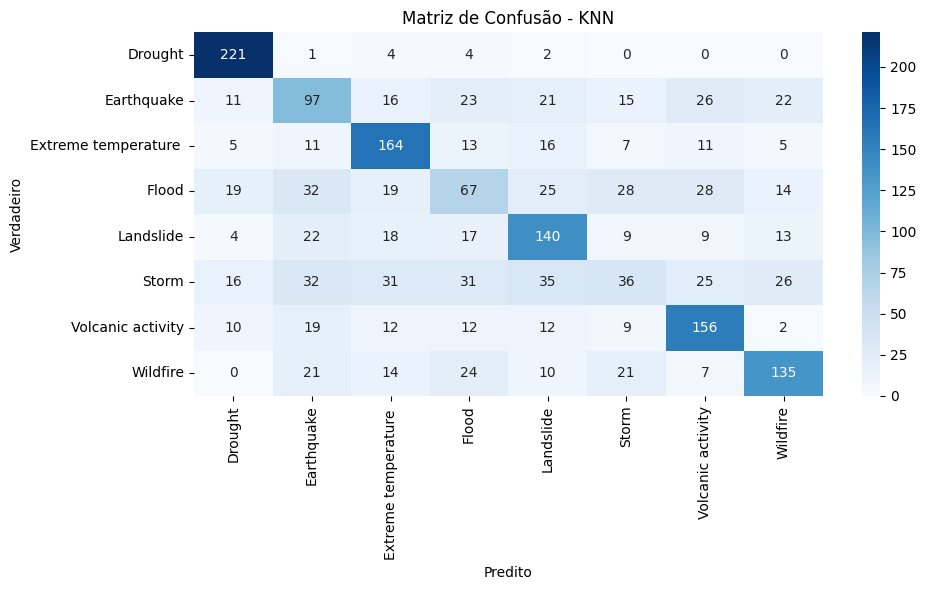


=== Modelo: Decision Tree ===
Acurácia: 0.6997

Relatório de Classificação:
                      precision    recall  f1-score   support

             Drought       0.90      0.91      0.91       232
          Earthquake       0.59      0.61      0.60       231
Extreme temperature        0.82      0.90      0.86       232
               Flood       0.38      0.33      0.35       232
           Landslide       0.80      0.83      0.82       232
               Storm       0.35      0.33      0.34       232
   Volcanic activity       0.86      0.84      0.85       232
            Wildfire       0.83      0.84      0.83       232

            accuracy                           0.70      1855
           macro avg       0.69      0.70      0.69      1855
        weighted avg       0.69      0.70      0.69      1855



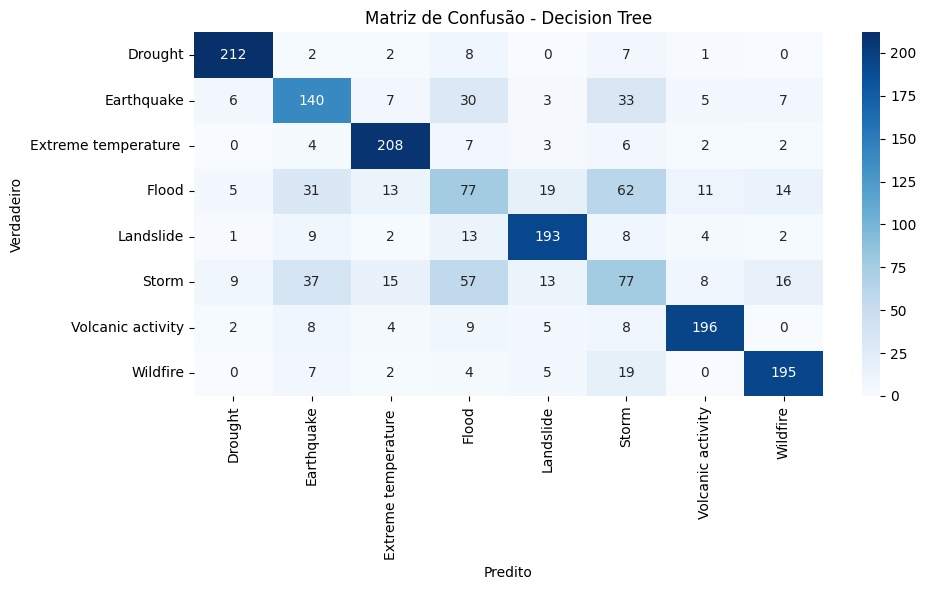


=== Modelo: Naive Bayes ===
Acurácia: 0.2609

Relatório de Classificação:
                      precision    recall  f1-score   support

             Drought       0.95      0.30      0.46       232
          Earthquake       0.36      0.07      0.12       231
Extreme temperature        0.24      0.13      0.17       232
               Flood       0.24      0.08      0.12       232
           Landslide       0.21      0.47      0.29       232
               Storm       0.19      0.03      0.05       232
   Volcanic activity       0.18      0.06      0.09       232
            Wildfire       0.24      0.94      0.39       232

            accuracy                           0.26      1855
           macro avg       0.33      0.26      0.21      1855
        weighted avg       0.33      0.26      0.21      1855



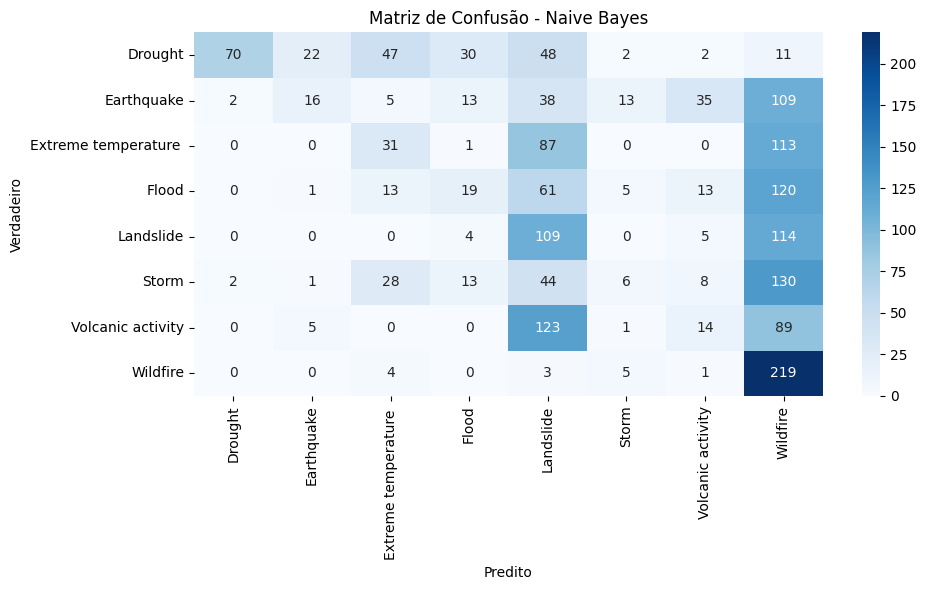


=== Modelo: SVM ===
Acurácia: 0.3633

Relatório de Classificação:
                      precision    recall  f1-score   support

             Drought       0.75      0.72      0.74       232
          Earthquake       0.48      0.25      0.33       231
Extreme temperature        0.27      0.74      0.40       232
               Flood       0.38      0.08      0.13       232
           Landslide       0.30      0.03      0.05       232
               Storm       0.32      0.03      0.06       232
   Volcanic activity       0.29      0.48      0.36       232
            Wildfire       0.33      0.58      0.42       232

            accuracy                           0.36      1855
           macro avg       0.39      0.36      0.31      1855
        weighted avg       0.39      0.36      0.31      1855



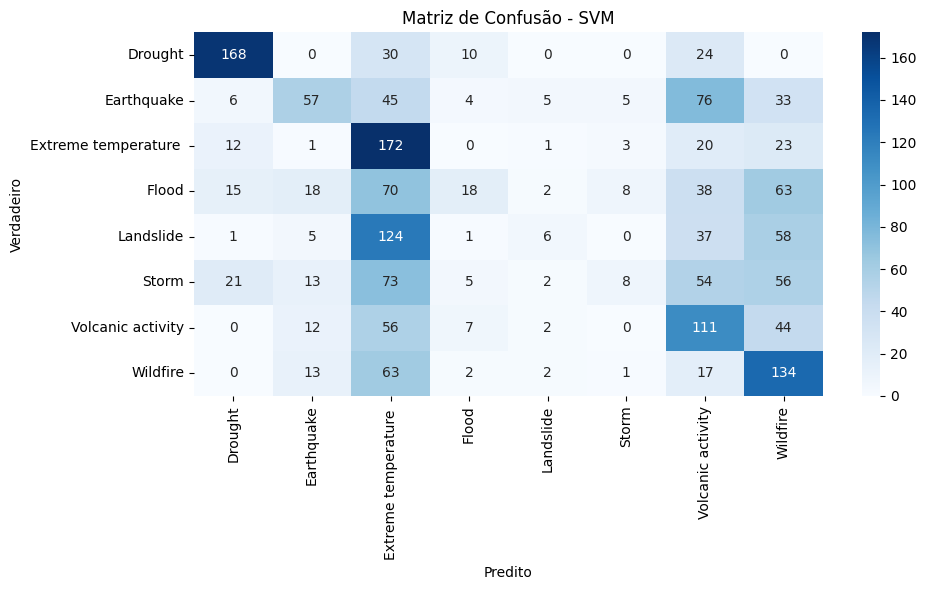


✅ Melhor modelo: Decision Tree com acurácia de 0.6997

Modelo salvo como 'modelo_disasters_melhor.pkl'


In [54]:
# === Classificação de Desastres Naturais: Avaliação com KNN, Árvores, Naive Bayes e SVM ===

# 1. Importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

# 2. Carregar o dataset
url = "https://raw.githubusercontent.com/GiovanaArisono/MVP-MACHINE-LEARNING/main/emdat.csv"
df = pd.read_csv(url, on_bad_lines='skip', sep=';')

# 3. Normalizar colunas
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^a-z0-9_]', '', regex=True)

# 4. Selecionar colunas de interesse
cols = ['disaster_type', 'year', 'total_deaths', 'total_affected', 'total_damage_usd_original']
df2 = df[cols].dropna()

# 5. Remover classes com menos de 6 exemplos
class_counts = df2['disaster_type'].value_counts()
valid_classes = class_counts[class_counts >= 6].index
df2 = df2[df2['disaster_type'].isin(valid_classes)]

# 6. Separar features e target
X = df2[['year', 'total_deaths', 'total_affected', 'total_damage_usd_original']]
y = df2['disaster_type']

# 7. Codificar target
le = LabelEncoder()
y_enc = le.fit_transform(y)

# 8. Balanceamento com SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_enc)

# 9. Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

# 10. Definir os modelos
models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(random_state=42)
}

# 11. Treinar, avaliar e armazenar resultados
melhor_modelo = None
melhor_nome = ""
melhor_acc = 0

for nome, modelo in models.items():
    print(f"\n=== Modelo: {nome} ===")

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', modelo)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"Acurácia: {acc:.4f}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Predito")
    plt.ylabel("Verdadeiro")
    plt.tight_layout()
    plt.show()

    if acc > melhor_acc:
        melhor_acc = acc
        melhor_nome = nome
        melhor_modelo = pipe

print(f"\n✅ Melhor modelo: {melhor_nome} com acurácia de {melhor_acc:.4f}")

# 12. Salvar o melhor modelo
joblib.dump((melhor_modelo, le), 'modelo_disasters_melhor.pkl')
print("\nModelo salvo como 'modelo_disasters_melhor.pkl'")